Edges in graph parallel

In [13]:
%pip install --quiet -U langgraph>=1.0.0


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from IPython.display import Image, display
from typing import  List,  TypedDict, Annotated,operator
from langgraph.graph import END, START, StateGraph

In [ ]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [ ]:
def node_a(state: State) -> State:
    print(f"Adding 'A': {state['nlist']}")
    return(State(nlist = ['A']))
def node_b(state: State) -> State:
    print(f"Adding 'B': {state['nlist']}")
    return(State(nlist = ['B']))
def node_c(state: State) -> State:
    print(f"Adding 'C': {state['nlist']}")
    return(State(nlist = ['C']))
def node_bb(state: State) -> State:
    print(f"Adding 'BB': {state['nlist']}")
    return(State(nlist = ['BB']))
def node_CC(state: State) -> State:
    print(f"Adding 'CC': {state['nlist']}")
    return(State(nlist = ['CC']))
def node_d(state: State) -> State:
    print(f"Adding 'D': {state['nlist']}")
    return(State(nlist = ['D']))


In [ ]:
builder = StateGraph(State)

builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)
builder.add_node("bb", node_bb)
builder.add_node("CC", node_CC)
builder.add_node("d", node_d)

builder.add_edge(START, "a")
builder.add_edge("a", "b")
builder.add_edge("a", "c")
builder.add_edge("b", "bb")
builder.add_edge("c", "CC")
builder.add_edge("bb", "d")
builder.add_edge("CC", "d")
builder.add_edge("d", END)
graph = builder.compile()


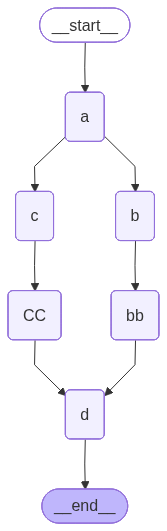

In [23]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
user_prompt = State(
    nlist = ["initial state"]
)
graph.invoke(user_prompt)

Adding 'A': ['initial state']
Adding 'B': ['initial state', 'A']
Adding 'C': ['initial state', 'A']
Adding 'CC': ['initial state', 'A', 'B', 'C']
Adding 'BB': ['initial state', 'A', 'B', 'C']
Adding 'D': ['initial state', 'A', 'B', 'C', 'CC', 'BB']


{'nlist': ['initial state', 'A', 'B', 'C', 'CC', 'BB', 'D']}